In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# **Importing Libraries and Tools**

In [1]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

# **Loading Datasets**

In [4]:
from sklearn.utils import shuffle
import os

train_dir = '/content/drive/MyDrive/MRI Images/Training/'
test_dir = '/content/drive/MyDrive/MRI Images/Testing/'

train_paths = []
train_labels = []

for label in sorted(os.listdir(train_dir)):
    label_path = os.path.join(train_dir, label)
    if not os.path.isdir(label_path):
        continue
    for image in os.listdir(label_path):
        if image.lower().endswith(('.png', '.jpg', '.jpeg')):
            train_paths.append(os.path.join(label_path, image))
            train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels, random_state=42)


test_paths = []
test_labels = []

for label in sorted(os.listdir(test_dir)):
    label_path = os.path.join(test_dir, label)
    if not os.path.isdir(label_path):
        continue
    for image in os.listdir(label_path):
        if image.lower().endswith(('.png', '.jpg', '.jpeg')):
            test_paths.append(os.path.join(label_path, image))
            test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels, random_state=42)

# **Data Visualization**

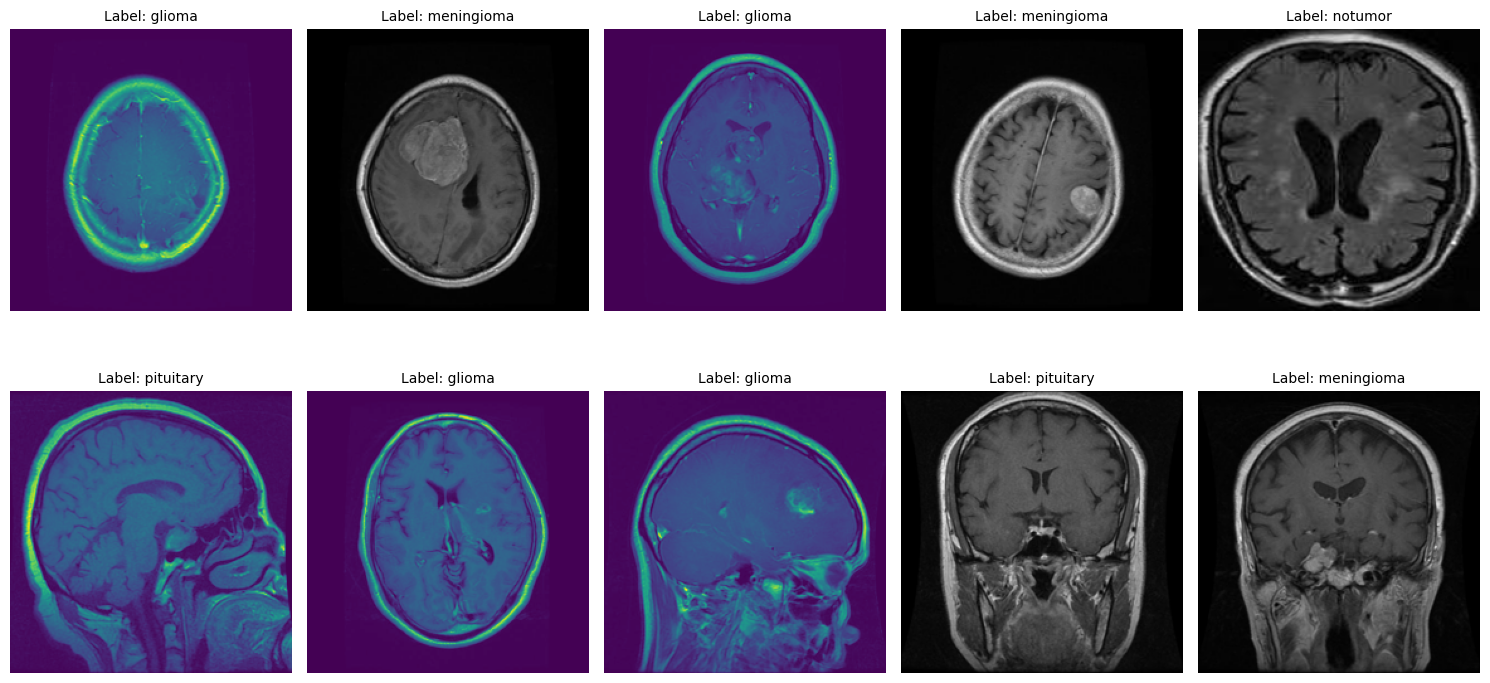

In [5]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os


random_indices = random.sample(range(len(train_paths)), 10)


fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):

    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))


    axes[i].imshow(img)
    axes[i].axis('off')

    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()

# **Image Preprocessing**

In [17]:
import tensorflow as tf

train_dir = '/content/drive/MyDrive/MRI Images/Training'
test_dir = '/content/drive/MyDrive/MRI Images/Testing'

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

raw_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True
)

raw_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

class_names = raw_train_ds.class_names

AUTOTUNE = tf.data.AUTOTUNE

train_ds = raw_train_ds.cache().prefetch(AUTOTUNE)
test_ds = raw_test_ds.cache().prefetch(AUTOTUNE)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


# **VGG16 Model for Transfer Learning**

In [18]:
from tensorflow.keras.layers import  GlobalAveragePooling2D

base_model = VGG16(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-4:]:
    layer.trainable = True

model = Sequential()
model.add(Input(shape=(224, 224, 3)))
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(len(class_names), activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15
)

Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 1029s 6s/step - accuracy: 0.7961 - loss: 0.5882 - val_accuracy: 0.8281 - val_loss: 0.5945
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 49s 282ms/step - accuracy: 0.9139 - loss: 0.2469 - val_accuracy: 0.9056 - val_loss: 0.3687
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 262ms/step - accuracy: 0.9593 - loss: 0.1289 - val_accuracy: 0.8975 - val_loss: 0.4916
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 48s 273ms/step - accuracy: 0.9680 - loss: 0.0960 - val_accuracy: 0.9237 - val_loss: 0.4034
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 47s 267ms/step - accuracy: 0.9787 - loss: 0.0640 - val_accuracy: 0.9456 - val_loss: 0.4570
Epoch 6/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 47s 270ms/step - accuracy: 0.9861 - loss: 0.0466 - val_accuracy: 0.9100 - val_loss: 0.4952
Epoch 7/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 47s 268ms/step - accuracy: 0.9873 - loss: 0.0415 - val_accuracy: 0.9413 - val_loss: 0.5296
Epoch 8/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 47s 267ms/step - accuracy: 0.9898 - loss: 0.

# **Model Training Plot**

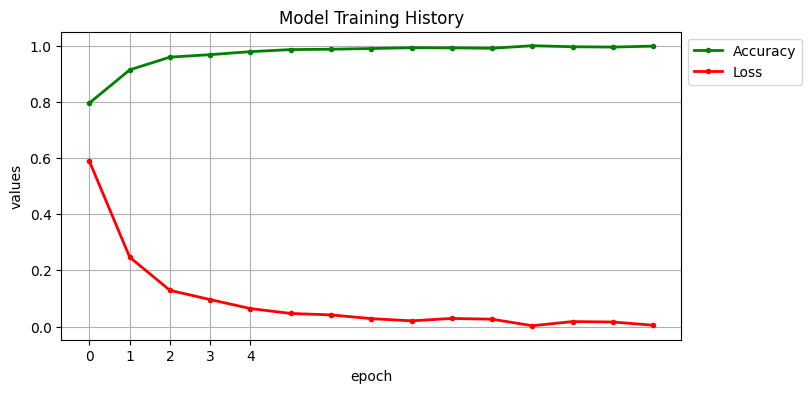

In [20]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.ylabel('values')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

# **Model Classification Report**

In [22]:
import numpy as np
from sklearn.metrics import classification_report

y_true = np.concatenate([y for x, y in test_ds], axis=0)

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 207ms/step
              precision    recall  f1-score   support

           0       0.99      0.81      0.89       400
           1       0.87      0.98      0.93       400
           2       0.95      1.00      0.98       400
           3       0.98      0.99      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



# **Confusion Matrix**

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step
Confusion Matrix:
[[323  54  18   5]
 [  3 394   1   2]
 [  0   0 400   0]
 [  0   3   0 397]]


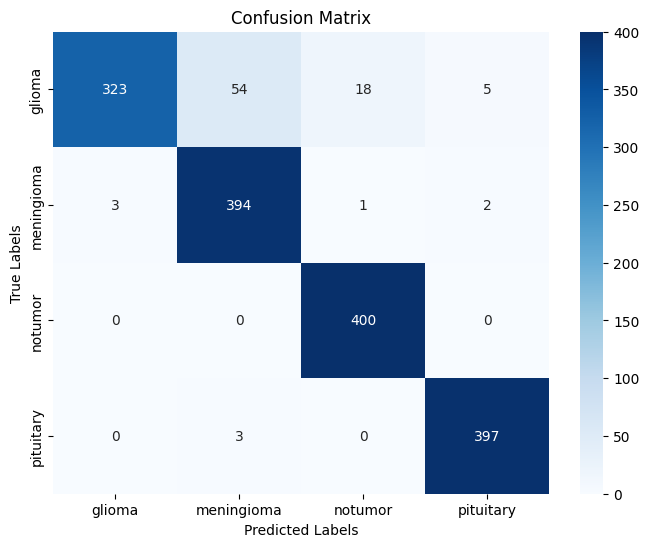

In [24]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

conf_matrix = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# **ROC Plot**

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 204ms/step


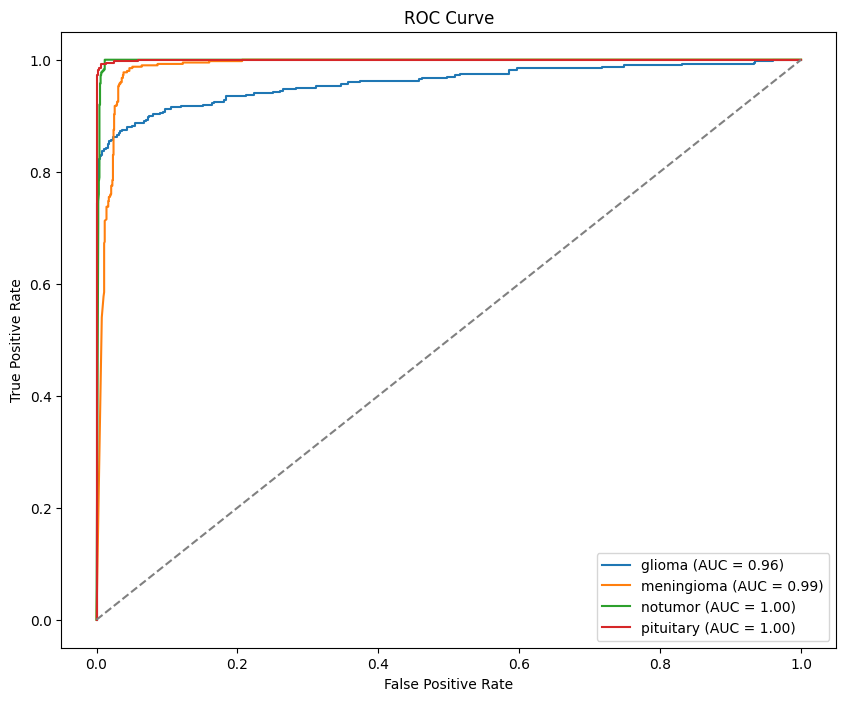

In [26]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)

num_classes = len(class_names)

y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.show()

# **Saving Model**

In [27]:
model.save('model.h5')

In [28]:
from tensorflow.keras.models import load_model

model = load_model('model.h5')

# **Brain Tumor Detection from MRI Scans**

In [29]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt


class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:

        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)


        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]


        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"


        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def detect_and_display(image_path, model):
    image = load_img(image_path, target_size=(224, 224))
    image_array = img_to_array(image) / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    prediction = model.predict(image_array)[0]

    predicted_index = np.argmax(prediction)
    confidence = prediction[predicted_index] * 100

    if class_names[predicted_index] == 'notumor':
        result = f"No Tumor "
    else:
        result = f"Tumor: {class_names[predicted_index]} "

    plt.imshow(image)
    plt.title(result)
    plt.axis("off")
    plt.show()

    return result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


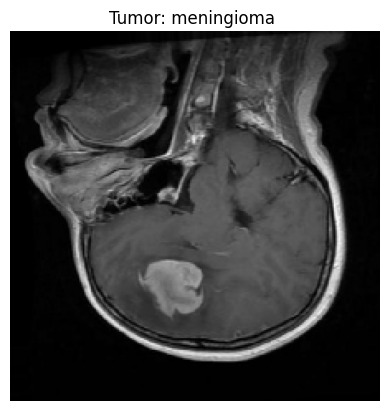

'Tumor: meningioma '

In [84]:
image_path = '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-aug-me_68.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


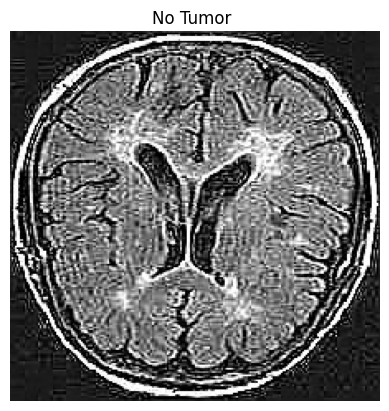

'No Tumor '

In [88]:
image_path = '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_3.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


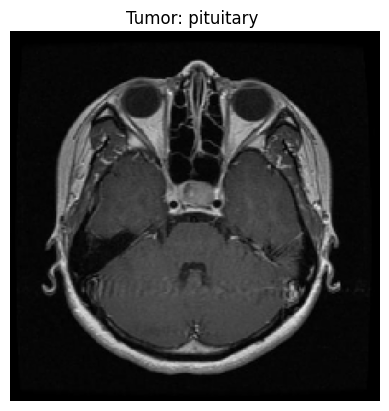

'Tumor: pituitary '

In [86]:
image_path = '/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-pi_183.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


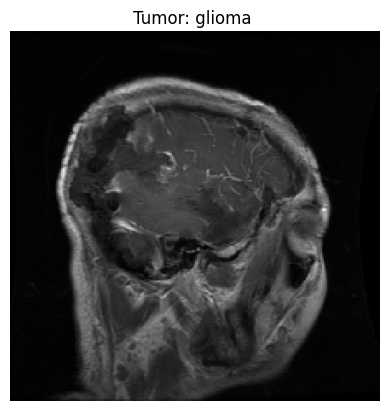

'Tumor: glioma '

In [87]:
image_path = '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_7.jpg'
detect_and_display(image_path, model)